In [15]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [10]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")
df.head(3)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2


In [16]:
# Sélection des features numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].dropna()

In [17]:
# Standardisation (important avant UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# UMAP 2D
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,      
    min_dist=0.1,        
    metric='euclidean',
    random_state=42
)

In [19]:
embedding = reducer.fit_transform(X_scaled)

c:\Users\rimze\OneDrive\Documents\M1\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
# Résultat dans un DataFrame
df_umap = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
df_umap['city_name'] = df['city_name'].values[:len(df_umap)]
df_umap['country'] = df['country'].values[:len(df_umap)]  

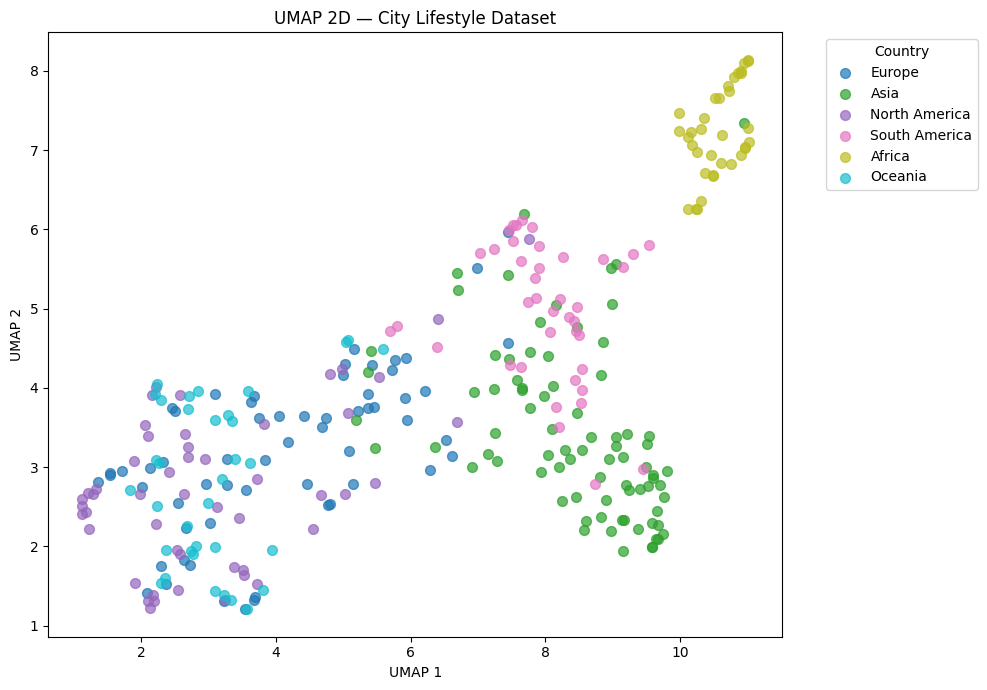

In [22]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))

countries = df_umap['country'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(countries)))

for country, color in zip(countries, colors):
    mask = df_umap['country'] == country
    ax.scatter(
        df_umap.loc[mask, 'UMAP_1'],
        df_umap.loc[mask, 'UMAP_2'],
        label=country, alpha=0.7, s=50, color=color
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP 2D — City Lifestyle Dataset')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

La projection UMAP en 2D met en évidence une structuration claire des villes selon leur région. On observe des regroupements distincts, notamment pour l’Afrique qui forme un cluster bien séparé en haut à droite. L’Asie et l’Amérique du Sud présentent également des zones relativement communes, tandis que l’Europe et l’Amérique du Nord montrent un léger chevauchement. Cela suggère que les caractéristiques du mode de vie capturent des similarités régionales tout en conservant certaines proximités entre continents.